In [53]:
import numpy as np
import matplotlib.pyplot as plt

from zeroheliumkit import GeomCollection, Rectangle
from zeroheliumkit.src.importing import Reader_Pickle
from zeroheliumkit.src.settings import *

from zeroheliumkit.fem.fieldreader import FreeFemResultParser, FieldAnalyzer
from zeroheliumkit.fem.fieldreader import make_cropped, make_masked, make_smooth, make_symmetric
from zeroheliumkit.src.settings import BLACK, WHITE
from zeroheliumkit.helpers.constants import qe, me, hbar

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [54]:
xy = [1,2,3,4,5,6,7,8]
xy[:-1]

[1, 2, 3, 4, 5, 6, 7]

In [41]:
#dir = "width_600nm/"
#ffparser = FreeFemResultParser(dir + "metadata.yaml", show=True)
#ffparser.get_capacitance_matrix()

In [55]:
# comparison between test_adapt and test_no_adapt:
ffparser_no_adapt = FreeFemResultParser("test_no_adapt/metadata.yaml", show=True)
ffparser_adapt = FreeFemResultParser("test_adapt/metadata.yaml", show=True)

import numpy as np
cm_no_adapt = np.array(ffparser_no_adapt.get_capacitance_matrix())
cm_adapt = np.array(ffparser_adapt.get_capacitance_matrix())

print("=== Without adaptation ===")
print(cm_no_adapt)
print("\n=== With adaptation ===")
print(cm_adapt)
print("\n=== Relative difference (%) ===")
print(np.round((cm_adapt - cm_no_adapt) / np.abs(cm_no_adapt) * 100, 2))

                result1
--------------  -------------
Quantity        phi
Plane           xy
X Min           -2.5
X Max           1.5
X Num           201
Y Min           -1
Y Max           1
Y Num           101
Slices          1
Slice Values    [0.26]
Curved Surface  False
Schema          (1, 101, 201)
Control Electrodes: ['ch', 'a', 'b', 'c', 'res', 'top']
                result1
--------------  -------------
Quantity        phi
Plane           xy
X Min           -2.5
X Max           1.5
X Num           201
Y Min           -1
Y Max           1
Y Num           101
Slices          1
Slice Values    [0.26]
Curved Surface  False
Schema          (1, 101, 201)
Control Electrodes: ['ch', 'a', 'b', 'c', 'res', 'top']
=== Without adaptation ===
[[-2.78304e+03  2.13602e+01  5.03380e+00  2.90730e+00  1.62655e+00
   2.78694e+03]
 [ 2.33564e+01 -3.49483e+02  1.91393e+01  2.37889e+00  5.40016e-01
   3.23941e+02]
 [ 5.39643e+00  1.79249e+01 -3.59998e+02  2.15338e+01  9.92486e-01
   3.62931e+02]
 [ 3

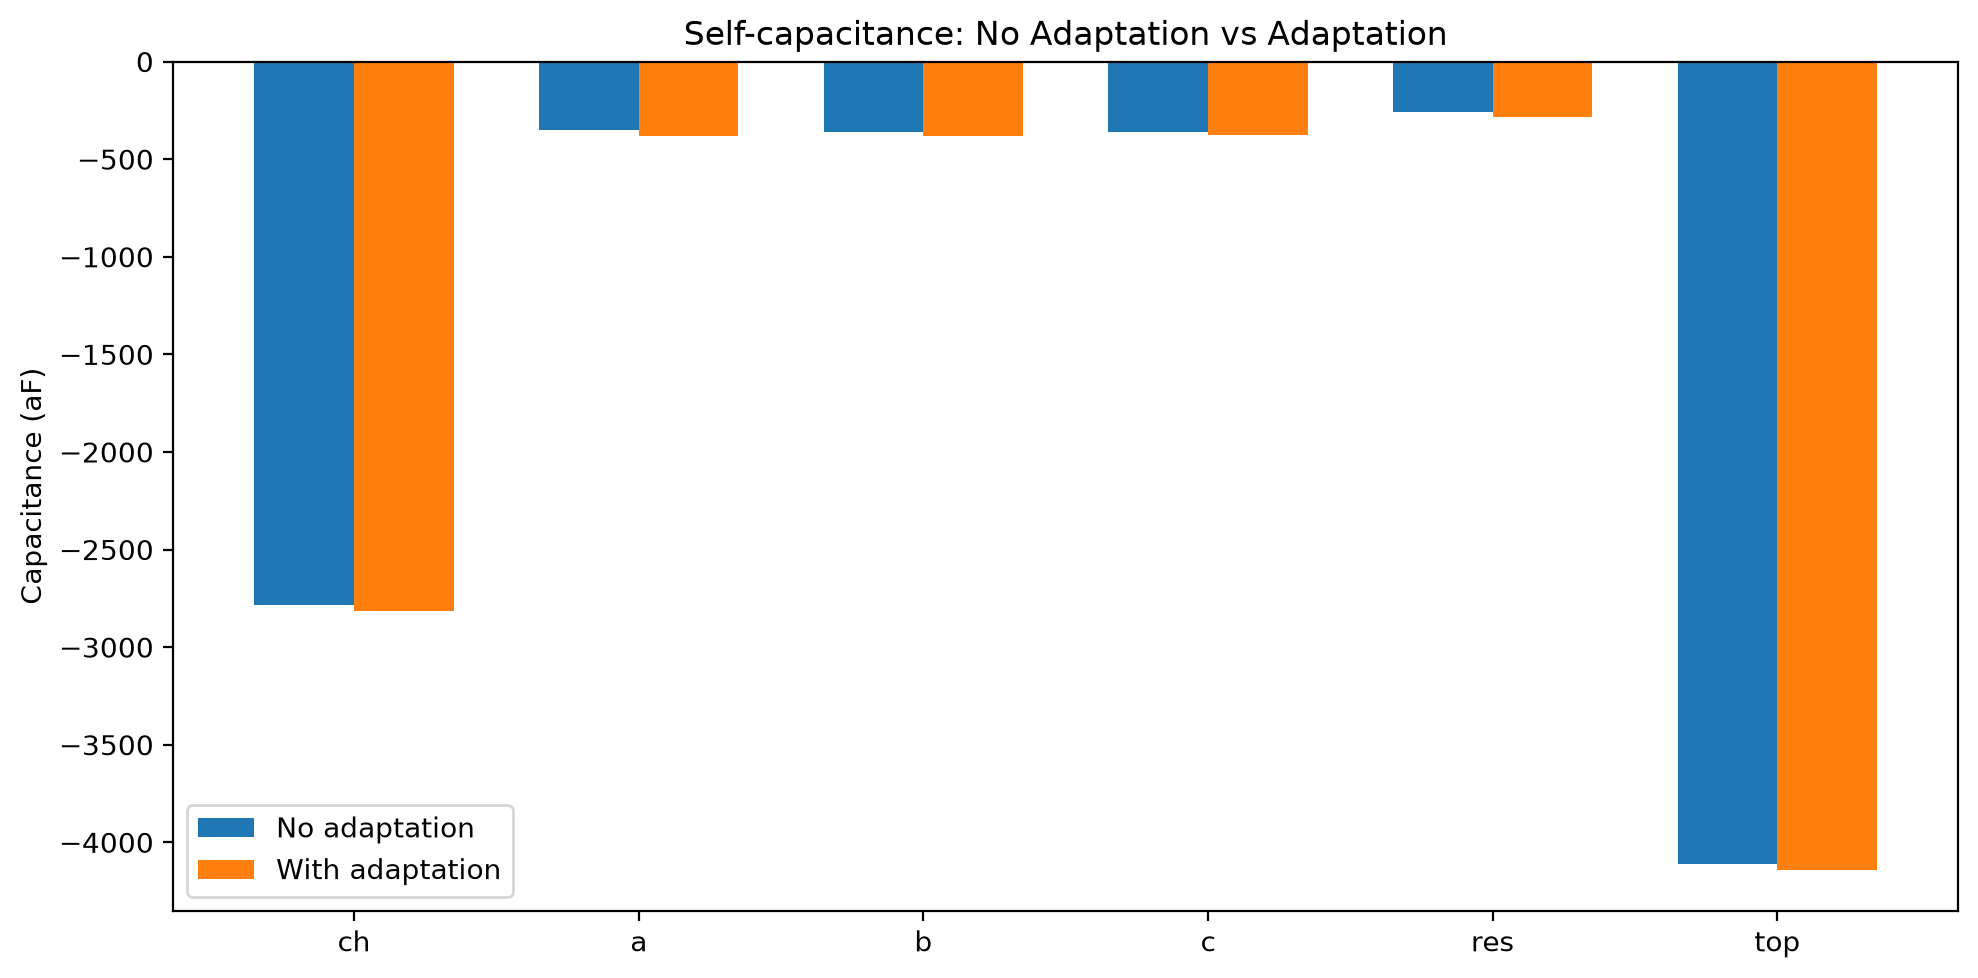

In [56]:
electrodes = ['ch', 'a', 'b', 'c', 'res', 'top']
diag_no_adapt = np.diag(cm_no_adapt)
diag_adapt = np.diag(cm_adapt)

x = np.arange(len(electrodes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, diag_no_adapt, width, label='No adaptation')
ax.bar(x + width/2, diag_adapt, width, label='With adaptation')
ax.set_xticks(x)
ax.set_xticklabels(electrodes)
ax.set_ylabel('Capacitance (aF)')
ax.set_title('Self-capacitance: No Adaptation vs Adaptation')
ax.legend()
plt.tight_layout()
plt.show()

In [57]:
#ffparser.load_data(dir + "results/", "result2")
ffparser_no_adapt.load_data("test_no_adapt/results/", "result1")
ffparser_adapt.load_data("test_adapt/results/", "result1")

In [58]:
#cc1 = ffparser.get_coupling_constants(slice_value=0.26, round_with_decimals=6)
#cc2 = make_symmetric(cc1, axis='x', symmetric_electrodes=['ch', 'a', 'b', 'c', 'res', 'top'])
#cc3 = make_smooth(cc2, sigma=2.0)
#cc4 = make_cropped(cc3, xrange=(-0.25,1), yrange=(-0.3,0.3))
# cc5 = make_masked(cc4, mask_area=Rectangle(0.4, 0.4, (0.6,0)))
cc_no_adapt = ffparser_no_adapt.get_coupling_constants(slice_value=0.26, round_with_decimals=6)
cc_adapt = ffparser_adapt.get_coupling_constants(slice_value=0.26, round_with_decimals=6)

In [59]:
cc_no_adapt.x.shape

(201,)

In [60]:
#fa = FieldAnalyzer(cc1)
#device = GeomCollection(layers=Reader_Pickle(dir + "geo/dot.pickle").geometries)
#device.top.color = (None, 0.0)
#device.bottom.color = (None, 0.)
fa_no_adapt = FieldAnalyzer(cc_no_adapt)
fa_adapt = FieldAnalyzer(cc_adapt)
device = GeomCollection(layers=Reader_Pickle("test_no_adapt/geo/dot.pickle").geometries)
device.top.color = (None, 0.0)
device.bottom.color = (None, 0.)

NameError: name 'fa' is not defined

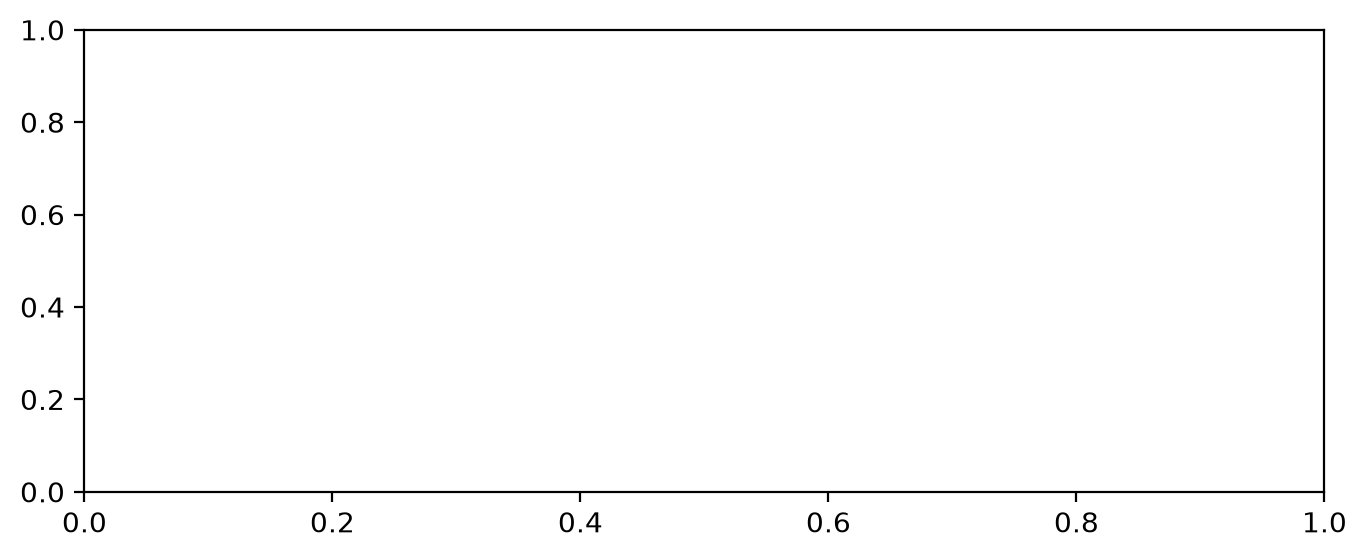

In [61]:
voltages = {
    'ch':       0,
    'a':        0, 
    'b':        0,
    'c':        0,
    'res':      1,
    'top':      0,
}

fig = plt.figure(figsize=(8, 3))
ax = fig.add_subplot(111)

fa.set_voltages(voltages)
fa.plot2D_data(ax=ax, zero_line=False, cmap='RdYlBu') # change this to 1D
device.top.plot(ax=ax, edgecolor=BLACK)
device.bottom.plot(ax=ax, edgecolor=LIGHTGRAY)
# device.plot(ax=ax, layer=["bottom"], color=[WHITE], alpha=0.1)
ax.set_xlim(-1., 1.)
ax.set_ylim(-0.5, 0.5)
ax.set_aspect("equal")

plt.show()
# use 1 dimensional plot
# and produce 1 plot comparing the both results

/var/folders/cs/qhd03p2d7jbc52xf4cfs6md40000gn/T/ipykernel_46475/2355277984.py:32: RuntimeWarning: invalid value encountered in divide
  axes[1].plot(cc_adapt.x, np.abs(data_adapt - data_no_adapt)/data_no_adapt)


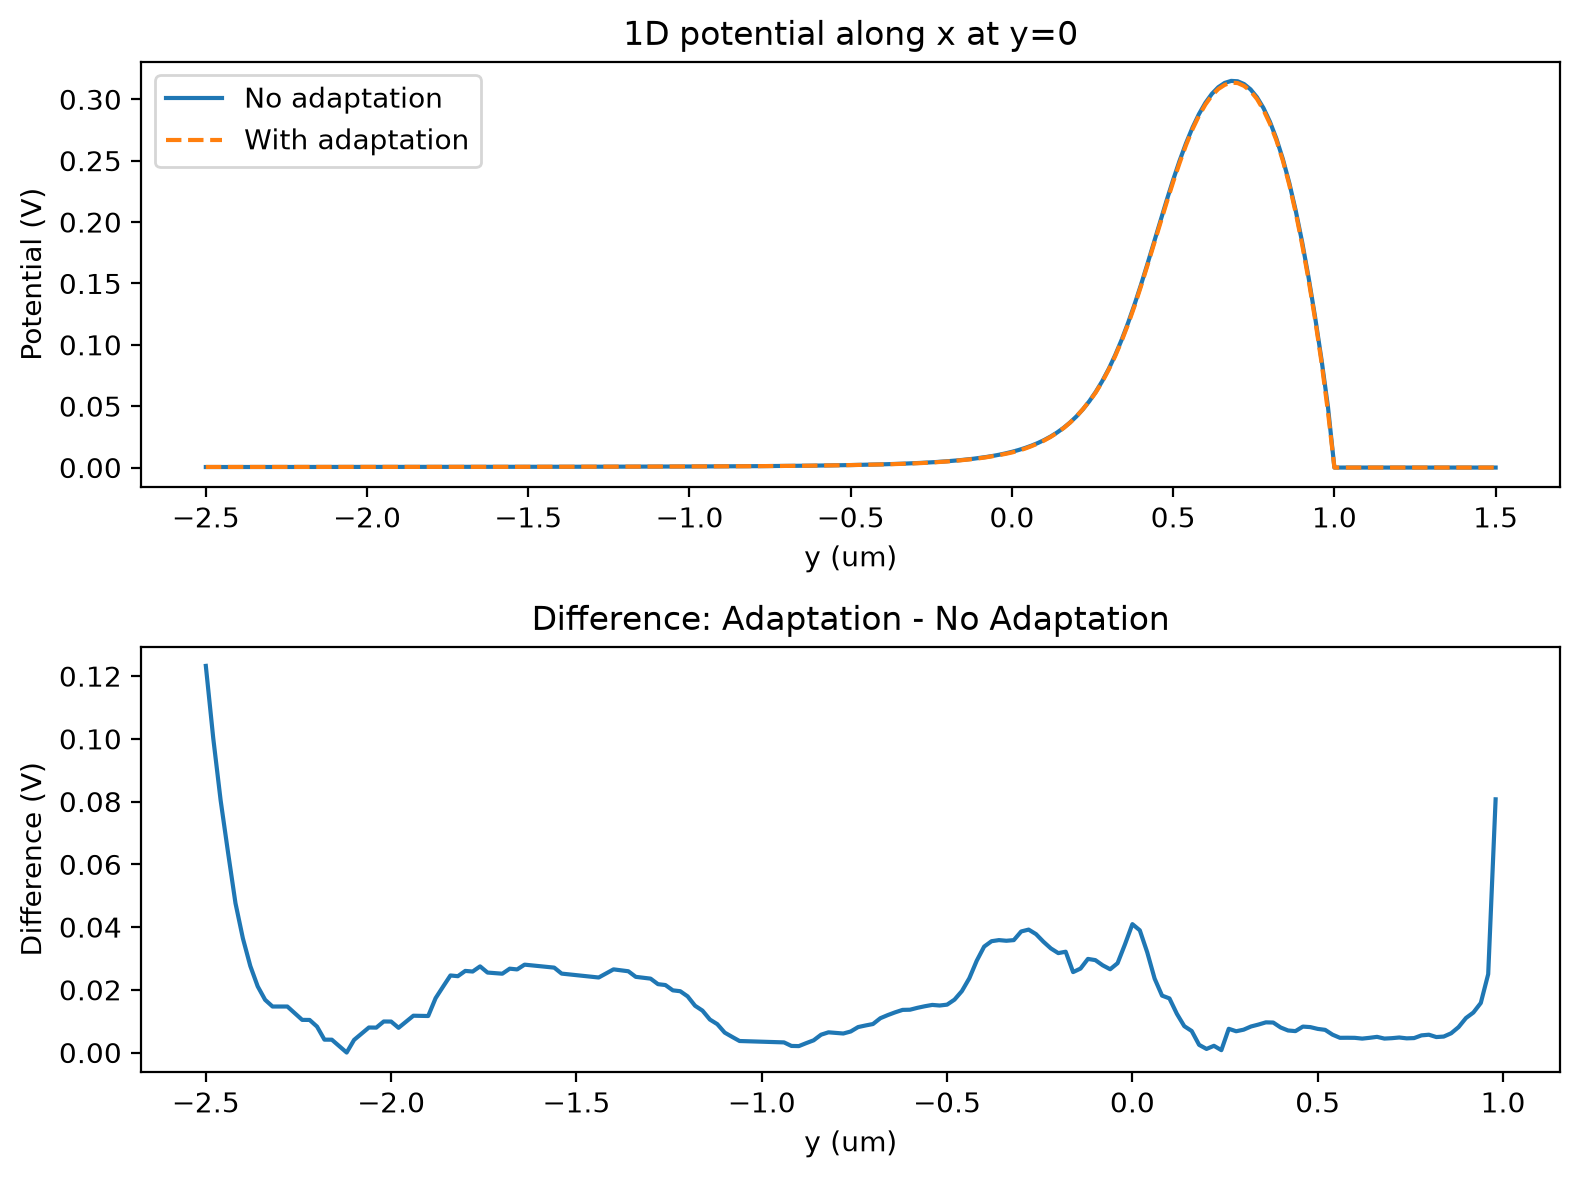

In [62]:
import numpy as np

# x axis creating:
x = np.linspace(-1, 1, 101)

voltages = {
    'ch':       0,
    'a':        0, 
    'b':        0,
    'c':        0,
    'res':      1,
    'top':      0,
}

fa_no_adapt.set_voltages(voltages)
fa_adapt.set_voltages(voltages)

data_no_adapt = fa_no_adapt.get_data(slice=('x', 0))
data_adapt = fa_adapt.get_data(slice=('x', 0))

fig, axes = plt.subplots(2, 1, figsize=(8, 6))

# Plot both on same axis
axes[0].plot(cc_no_adapt.x, data_no_adapt, label='No adaptation')
axes[0].plot(cc_adapt.x, data_adapt, label='With adaptation', linestyle='--')
axes[0].set_xlabel('y (um)')
axes[0].set_ylabel('Potential (V)')
axes[0].set_title('1D potential along x at y=0')
axes[0].legend()

# Plot difference
axes[1].plot(cc_adapt.x, np.abs(data_adapt - data_no_adapt)/data_no_adapt)
axes[1].set_xlabel('y (um)')
axes[1].set_ylabel('Difference (V)')
axes[1].set_title('Difference: Adaptation - No Adaptation')

plt.tight_layout()
plt.show()

In [63]:
ffparser_no_adapt_coarse = FreeFemResultParser("test_no_adapt_coarse/metadata.yaml", show=True)
ffparser_adapt_coarse = FreeFemResultParser("test_adapt_coarse/metadata.yaml", show=True)

cm_no_adapt_coarse = np.array(ffparser_no_adapt_coarse.get_capacitance_matrix())
cm_adapt_coarse = np.array(ffparser_adapt_coarse.get_capacitance_matrix())

print("=== Without adaptation (coarse) ===")
print(cm_no_adapt_coarse)
print("\n=== With adaptation (coarse) ===")
print(cm_adapt_coarse)
print("\n=== Relative difference (%) ===")
print(np.round((cm_adapt_coarse - cm_no_adapt_coarse) / np.abs(cm_no_adapt_coarse) * 100, 2))

                result1        result2        result3
--------------  -------------  -------------  -------------
Quantity        phi            phi            Ez
Plane           xy             xy             xy
X Min           -2.5           -1.5           -1.5
X Max           1.5            1              1
X Num           201            251            251
Y Min           -1             -0.6           -0.6
Y Max           1              0.6            0.6
Y Num           101            151            151
Slices          1              2              1
Slice Values    [0.26]         [0.26, 0.29]   [0.26]
Curved Surface  False          False          False
Schema          (1, 101, 201)  (2, 151, 251)  (1, 151, 251)
Control Electrodes: ['ch', 'a', 'b', 'c', 'res', 'top']
                result1
--------------  -------------
Quantity        phi
Plane           xy
X Min           -2.5
X Max           1.5
X Num           201
Y Min           -1
Y Max           1
Y Num           101
Slices  

In [64]:
ffparser_no_adapt_coarse.load_data("test_no_adapt_coarse/results/", "result1")
ffparser_adapt_coarse.load_data("test_adapt_coarse/results/", "result1")

cc_no_adapt_coarse = ffparser_no_adapt_coarse.get_coupling_constants(slice_value=0.26, round_with_decimals=6)
cc_adapt_coarse = ffparser_adapt_coarse.get_coupling_constants(slice_value=0.26, round_with_decimals=6)

fa_no_adapt_coarse = FieldAnalyzer(cc_no_adapt_coarse)
fa_adapt_coarse = FieldAnalyzer(cc_adapt_coarse)

/var/folders/cs/qhd03p2d7jbc52xf4cfs6md40000gn/T/ipykernel_46475/3898417994.py:25: RuntimeWarning: invalid value encountered in divide
  axes[1].plot(cc_adapt_coarse.x, np.abs(data_adapt_coarse - data_no_adapt_coarse) / data_no_adapt_coarse)


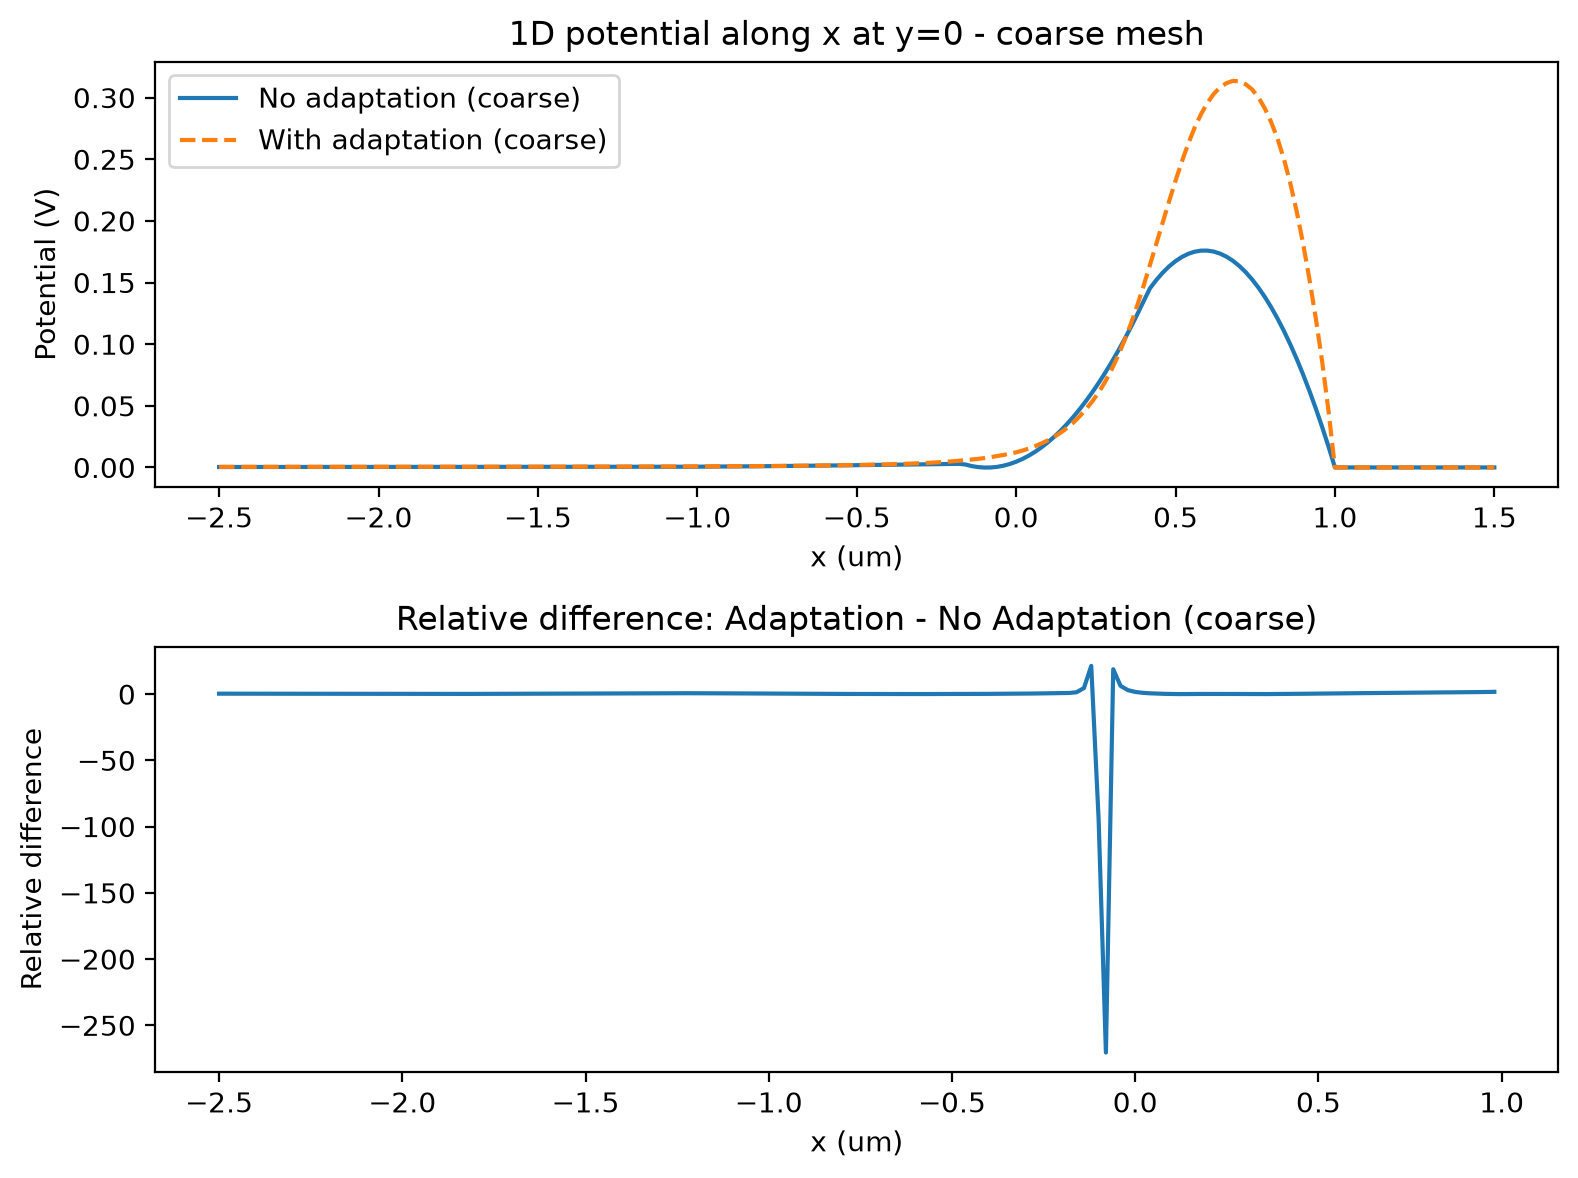

In [67]:
voltages = {
    'ch':       0,
    'a':        0, 
    'b':        0,
    'c':        0,
    'res':      1,
    'top':      0,
}

fa_no_adapt_coarse.set_voltages(voltages)
fa_adapt_coarse.set_voltages(voltages)

data_no_adapt_coarse = fa_no_adapt_coarse.get_data(slice=('x', 0))
data_adapt_coarse = fa_adapt_coarse.get_data(slice=('x', 0))

fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].plot(cc_no_adapt_coarse.x, data_no_adapt_coarse, label='No adaptation (coarse)')
axes[0].plot(cc_adapt_coarse.x, data_adapt_coarse, label='With adaptation (coarse)', linestyle='--')
axes[0].set_xlabel('x (um)')
axes[0].set_ylabel('Potential (V)')
axes[0].set_title('1D potential along x at y=0 - coarse mesh')
axes[0].legend()

axes[1].plot(cc_adapt_coarse.x, np.abs(data_adapt_coarse - data_no_adapt_coarse) / data_no_adapt_coarse)
axes[1].set_xlabel('x (um)')
axes[1].set_ylabel('Relative difference')
axes[1].set_title('Relative difference: Adaptation - No Adaptation (coarse)')

plt.tight_layout()
plt.show()

/var/folders/cs/qhd03p2d7jbc52xf4cfs6md40000gn/T/ipykernel_46475/2439082844.py:31: RuntimeWarning: invalid value encountered in divide
  axes[1].plot(cc_adapt.x, np.abs(data_adapt - data_no_adapt) / data_no_adapt, label='Fine mesh')
/var/folders/cs/qhd03p2d7jbc52xf4cfs6md40000gn/T/ipykernel_46475/2439082844.py:32: RuntimeWarning: invalid value encountered in divide
  axes[1].plot(cc_adapt_coarse.x, np.abs(data_adapt_coarse - data_no_adapt_coarse) / data_no_adapt_coarse, label='Coarse mesh')


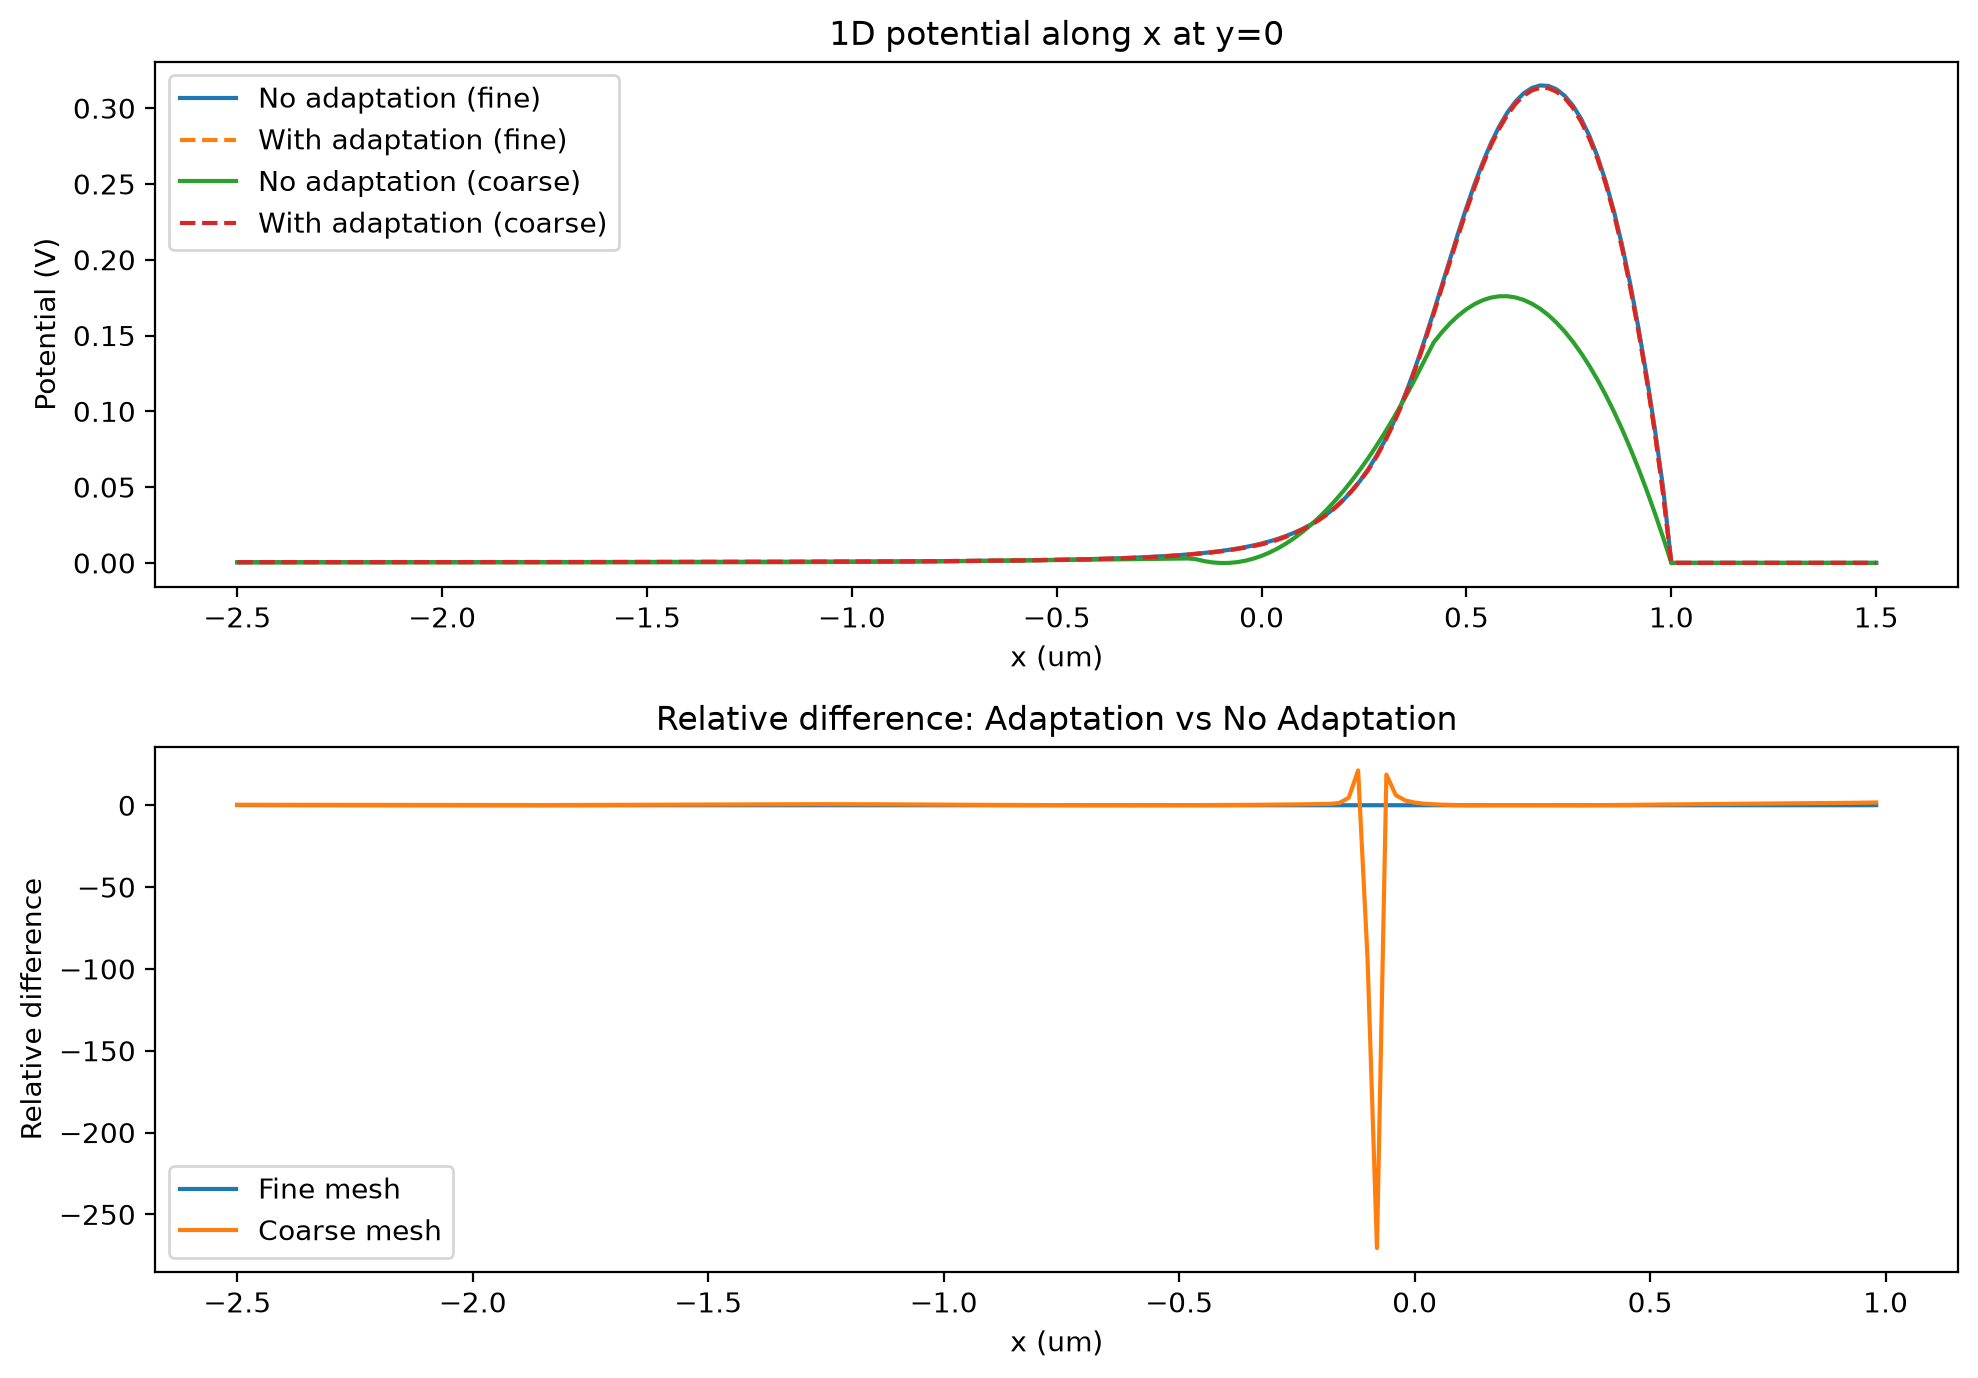

In [68]:
voltages = {
    'ch':       0,
    'a':        0, 
    'b':        0,
    'c':        0,
    'res':      1,
    'top':      0,
}

fa_no_adapt.set_voltages(voltages)
fa_adapt.set_voltages(voltages)
fa_no_adapt_coarse.set_voltages(voltages)
fa_adapt_coarse.set_voltages(voltages)

data_no_adapt = fa_no_adapt.get_data(slice=('x', 0))
data_adapt = fa_adapt.get_data(slice=('x', 0))
data_no_adapt_coarse = fa_no_adapt_coarse.get_data(slice=('x', 0))
data_adapt_coarse = fa_adapt_coarse.get_data(slice=('x', 0))

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(cc_no_adapt.x, data_no_adapt, label='No adaptation (fine)')
axes[0].plot(cc_adapt.x, data_adapt, label='With adaptation (fine)', linestyle='--')
axes[0].plot(cc_no_adapt_coarse.x, data_no_adapt_coarse, label='No adaptation (coarse)')
axes[0].plot(cc_adapt_coarse.x, data_adapt_coarse, label='With adaptation (coarse)', linestyle='--')
axes[0].set_xlabel('x (um)')
axes[0].set_ylabel('Potential (V)')
axes[0].set_title('1D potential along x at y=0')
axes[0].legend()

axes[1].plot(cc_adapt.x, np.abs(data_adapt - data_no_adapt) / data_no_adapt, label='Fine mesh')
axes[1].plot(cc_adapt_coarse.x, np.abs(data_adapt_coarse - data_no_adapt_coarse) / data_no_adapt_coarse, label='Coarse mesh')
axes[1].set_xlabel('x (um)')
axes[1].set_ylabel('Relative difference')
axes[1].set_title('Relative difference: Adaptation vs No Adaptation')
axes[1].legend()

plt.tight_layout()
plt.show()

/var/folders/cs/qhd03p2d7jbc52xf4cfs6md40000gn/T/ipykernel_46475/3317587928.py:30: RuntimeWarning: invalid value encountered in divide
  axes[0, 1].plot(cc_adapt.x, np.abs(data_adapt - data_no_adapt) / np.abs(data_no_adapt))
/var/folders/cs/qhd03p2d7jbc52xf4cfs6md40000gn/T/ipykernel_46475/3317587928.py:43: RuntimeWarning: invalid value encountered in divide
  axes[1, 1].plot(cc_no_adapt_coarse.x, np.abs(data_no_adapt_coarse - data_no_adapt) / np.abs(data_no_adapt))
/var/folders/cs/qhd03p2d7jbc52xf4cfs6md40000gn/T/ipykernel_46475/3317587928.py:56: RuntimeWarning: invalid value encountered in divide
  axes[2, 1].plot(cc_adapt_coarse.x, np.abs(data_adapt_coarse - data_no_adapt) / np.abs(data_no_adapt))


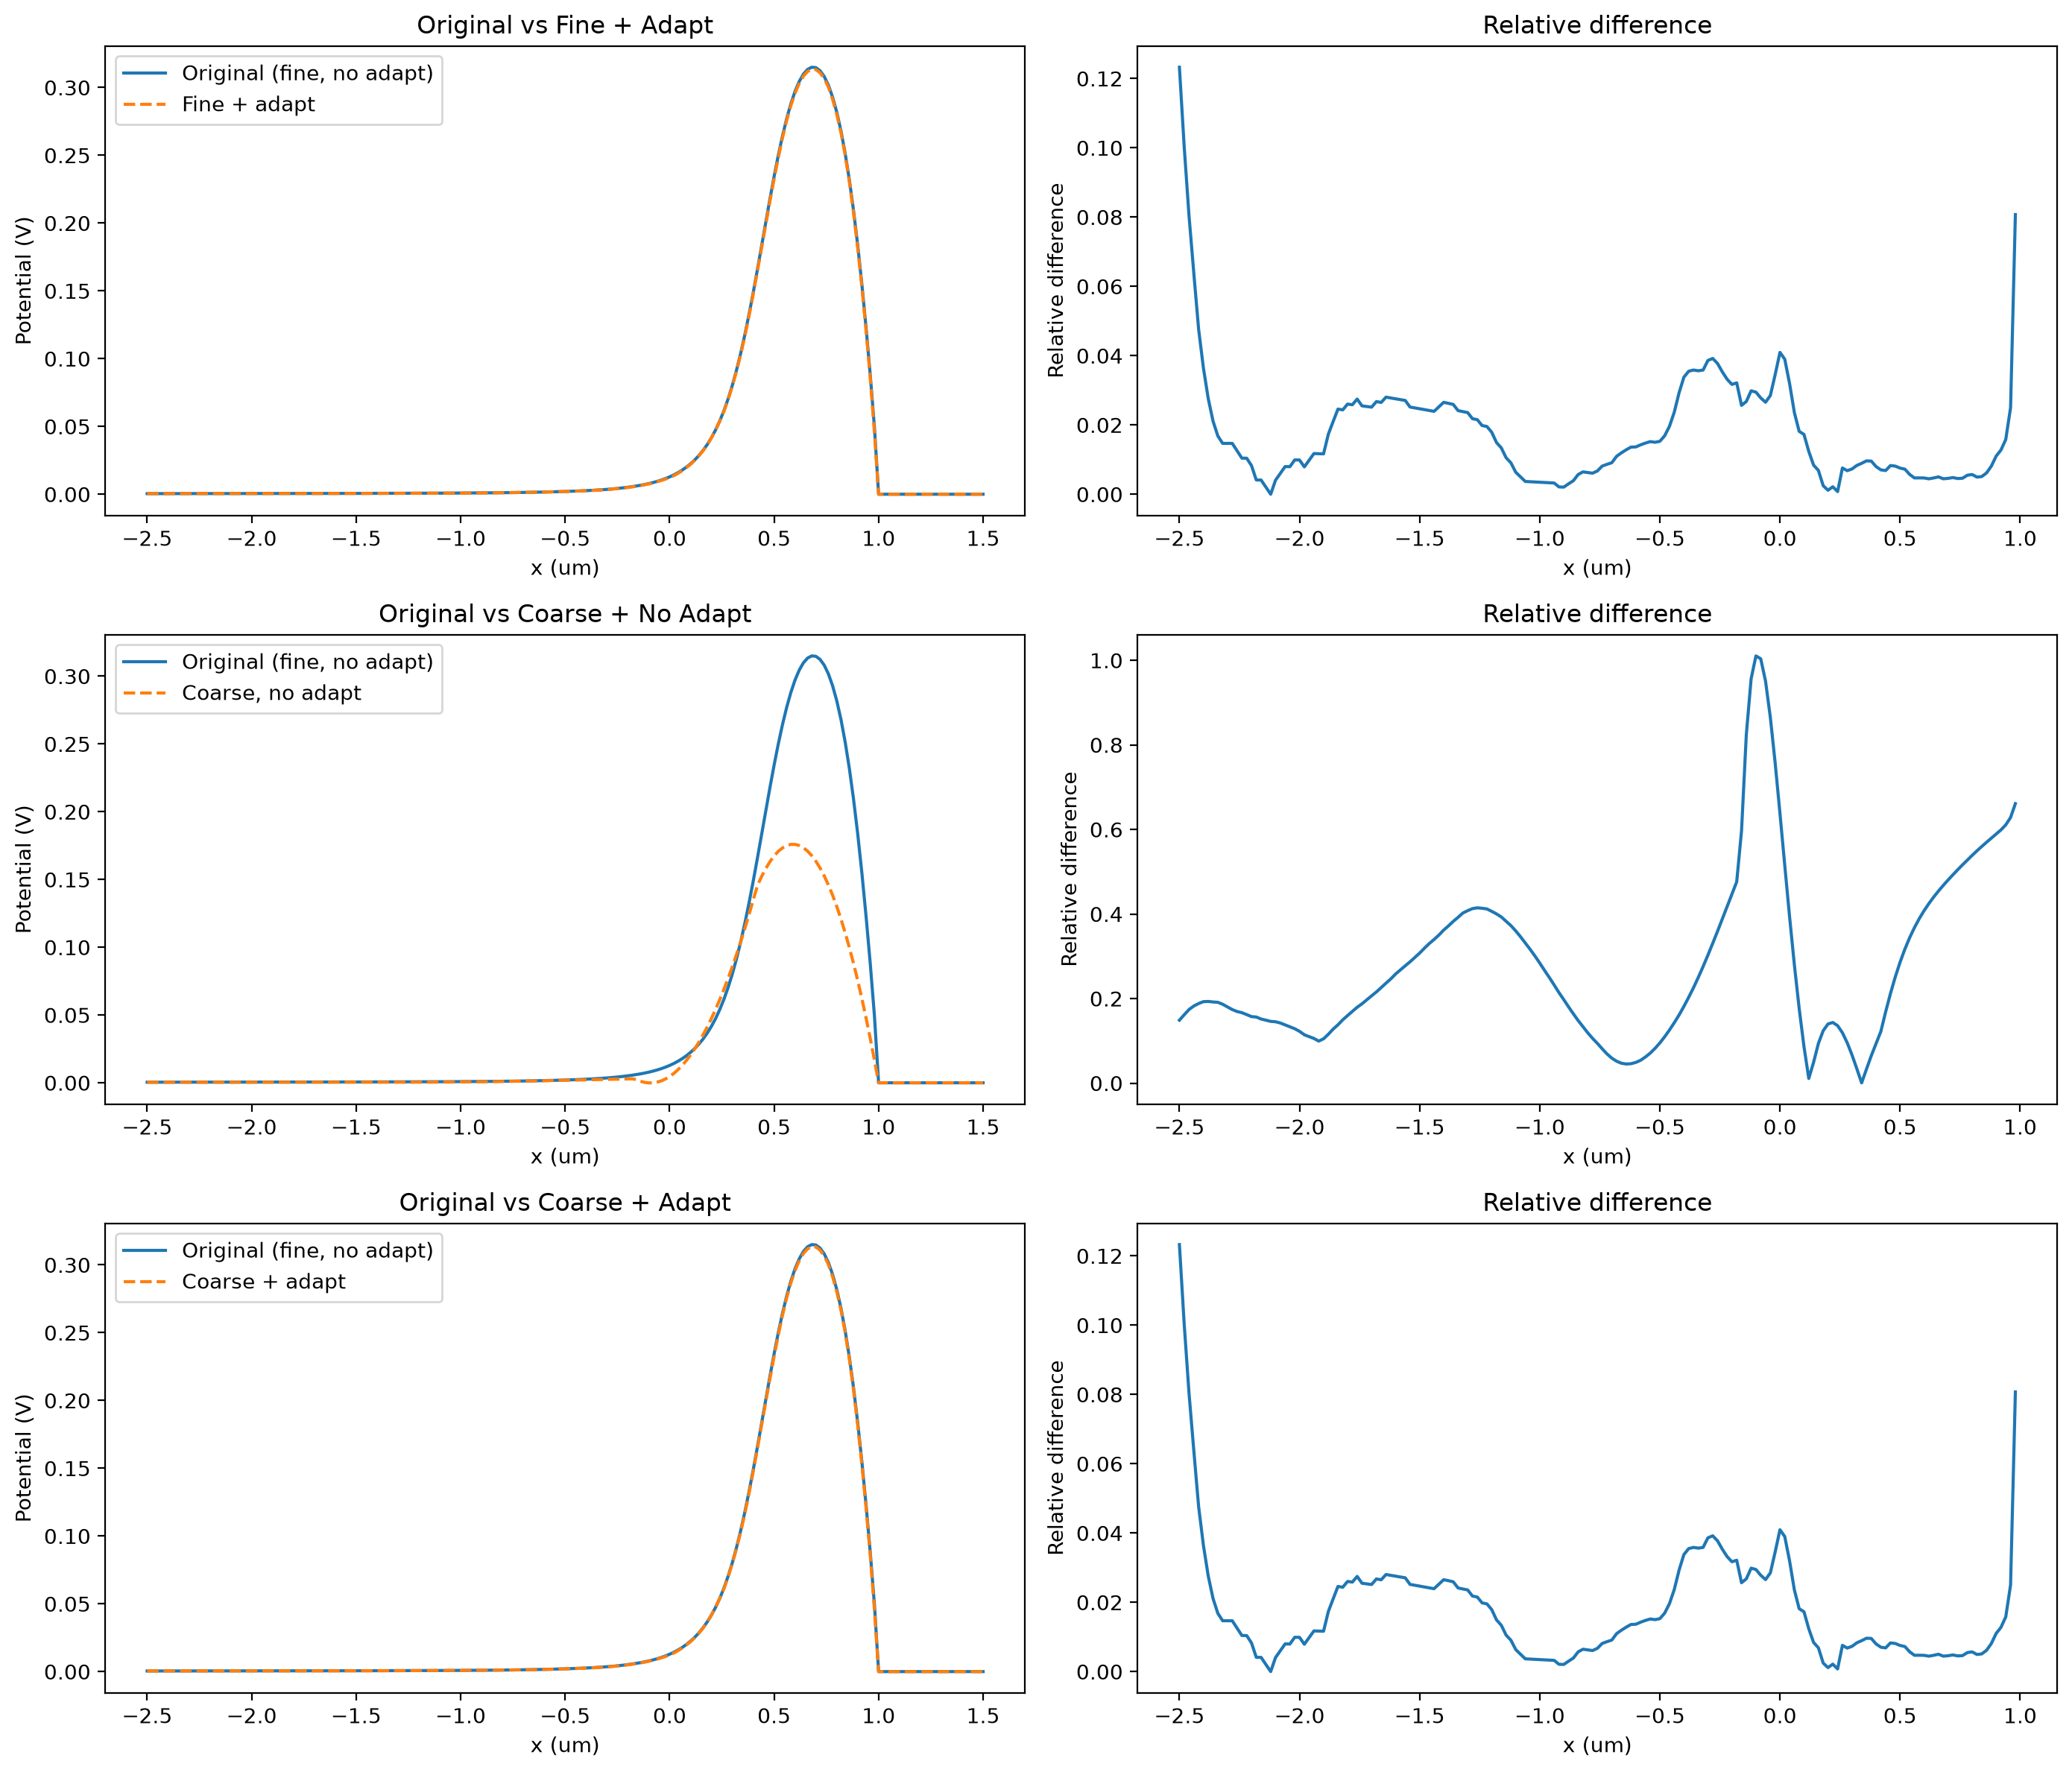

In [ ]:
# Original: fine and no adapt
voltages = {
    'ch':       0,
    'a':        0, 
    'b':        0,
    'c':        0,
    'res':      1,
    'top':      0,
}

fa_no_adapt.set_voltages(voltages)
fa_adapt.set_voltages(voltages)
fa_no_adapt_coarse.set_voltages(voltages)
fa_adapt_coarse.set_voltages(voltages)

data_no_adapt = fa_no_adapt.get_data(slice=('x', 0))
data_adapt = fa_adapt.get_data(slice=('x', 0))
data_no_adapt_coarse = fa_no_adapt_coarse.get_data(slice=('x', 0))
data_adapt_coarse = fa_adapt_coarse.get_data(slice=('x', 0))

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Plot 1: original vs fine + adapt
axes[0, 0].plot(cc_no_adapt.x, data_no_adapt, label='Original (fine, no adapt)')
axes[0, 0].plot(cc_adapt.x, data_adapt, label='Fine + adapt', linestyle='--')
axes[0, 0].set_xlabel('x (um)')
axes[0, 0].set_ylabel('Potential (V)')
axes[0, 0].set_title('Original vs Fine + Adapt')
axes[0, 0].legend()

axes[0, 1].plot(cc_adapt.x, np.abs(data_adapt - data_no_adapt) / np.abs(data_no_adapt))
axes[0, 1].set_xlabel('x (um)')
axes[0, 1].set_ylabel('Relative difference')
axes[0, 1].set_title('Relative difference')

# Plot 2: original vs coarse + no adapt
axes[1, 0].plot(cc_no_adapt.x, data_no_adapt, label='Original (fine, no adapt)')
axes[1, 0].plot(cc_no_adapt_coarse.x, data_no_adapt_coarse, label='Coarse, no adapt', linestyle='--')
axes[1, 0].set_xlabel('x (um)')
axes[1, 0].set_ylabel('Potential (V)')
axes[1, 0].set_title('Original vs Coarse + No Adapt')
axes[1, 0].legend()

axes[1, 1].plot(cc_no_adapt_coarse.x, np.abs(data_no_adapt_coarse - data_no_adapt) / np.abs(data_no_adapt))
axes[1, 1].set_xlabel('x (um)')
axes[1, 1].set_ylabel('Relative difference')
axes[1, 1].set_title('Relative difference')

# Plot 3: original vs coarse + adapt
axes[2, 0].plot(cc_no_adapt.x, data_no_adapt, label='Original (fine, no adapt)')
axes[2, 0].plot(cc_adapt_coarse.x, data_adapt_coarse, label='Coarse + adapt', linestyle='--')
axes[2, 0].set_xlabel('x (um)')
axes[2, 0].set_ylabel('Potential (V)')
axes[2, 0].set_title('Original vs Coarse + Adapt')
axes[2, 0].legend()

axes[2, 1].plot(cc_adapt_coarse.x, np.abs(data_adapt_coarse - data_no_adapt) / np.abs(data_no_adapt))
axes[2, 1].set_xlabel('x (um)')
axes[2, 1].set_ylabel('Relative difference')
axes[2, 1].set_title('Relative difference')

plt.tight_layout()
plt.show()

In [8]:
# import sys
# sys.path.append(r'/Users/helium/Documents/git/eeroqlab/chargequbit/')

# from schrodinger2d import SingleElectron
# from qubit_calculator import Resonator, QuantumDot, QubitProperties

from chargequbit import TrapPotential, Resonator, ChargeQubit

In [9]:
res = Resonator(type="1/4", couplings=cc4, names=['res'], resonance_frequency=7.1e9, total_capacitance=5.25e-15)
res.get_field(0.45,0)

(array(0.86397197), array(0.))

In [11]:
qd = TrapPotential(x = cc4.x, y = cc4.y, potential = fa.potential)
qd.find_trap()
qd.well

{'exist': True,
 'ij': (np.int64(69), np.int64(38)),
 'xy': (np.float64(0.43999999999999995), np.float64(0.0)),
 'value': np.float64(0.004058190458696353),
 'type': 'max'}

array([0.00000000e+00, 9.50946699e+09, 1.88673169e+10, 1.89610484e+10,
       2.81380993e+10, 2.84453885e+10, 3.73721176e+10, 3.77720502e+10,
       3.79111277e+10, 4.66072674e+10])

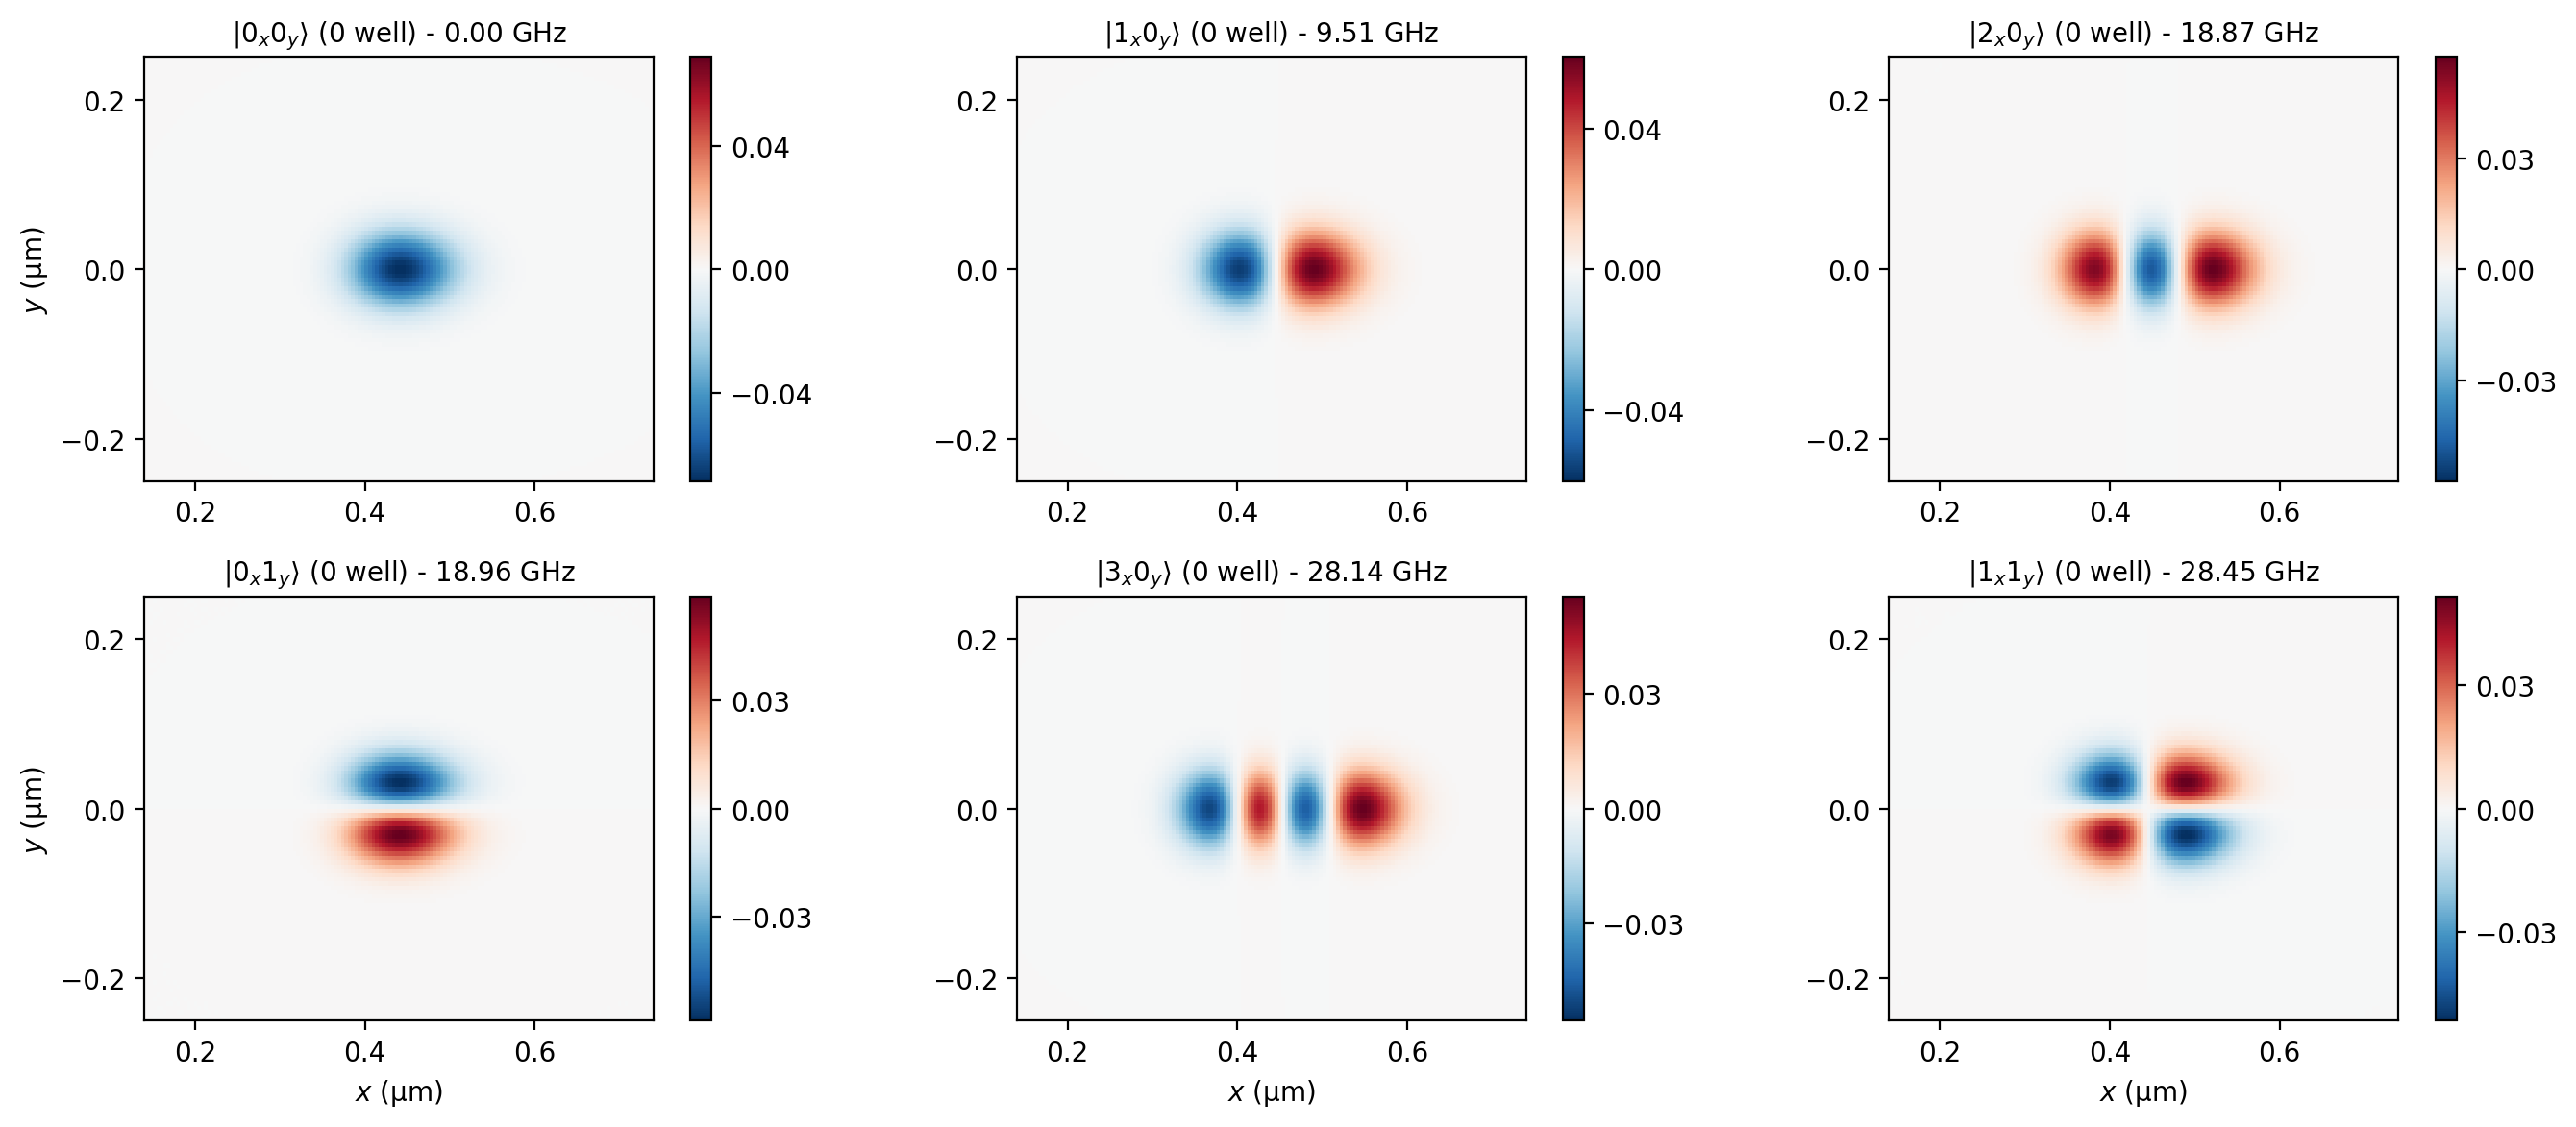

In [12]:
qp = ChargeQubit(resonator=res, trap=qd)
qp.get_spectrum(dxdy=[0.6,0.5], plot_wavefunctions=True)

In [13]:
qp.get_properties()

{'x': {'fe (GHz)': np.float64(9.509467),
  'Vzpf (uV)': np.float64(21.2),
  'le (nm)': np.float64(31.1),
  'lr (nm)': np.float64(36.0),
  'anharmonicity (MHz)': np.float64(-151.6),
  'electric_field (1/um)': 0.86,
  'coupling_g (MHz)': np.float64(159.1),
  'frequency_shift (MHz)': np.float64(-17.9697),
  'capacitance_change (aF)': np.float64(13.29)},
 'y': {'fe (GHz)': np.float64(18.961048),
  'Vzpf (uV)': np.float64(21.2),
  'le (nm)': np.float64(31.1),
  'lr (nm)': np.float64(36.0),
  'anharmonicity (MHz)': np.float64(-11.0),
  'electric_field (1/um)': 0.0,
  'coupling_g (MHz)': np.float64(0.0),
  'frequency_shift (MHz)': np.float64(-0.0),
  'capacitance_change (aF)': np.float64(0.0)}}

In [9]:
xx = np.linspace(-1.0, 1.0, 201)
yy = np.linspace(-0.6, 0.6, 201)
def harmonic(omega_x, omega_y):
    X, Y = np.meshgrid(xx, yy, indexing='xy')
    return -0.5 * me * (omega_x**2 * (X*1e-6)**2 + omega_y**2 * (Y*1e-6)**2) / qe + 0.5

pot = harmonic(2*np.pi*5e9, 2*np.pi*7e9)


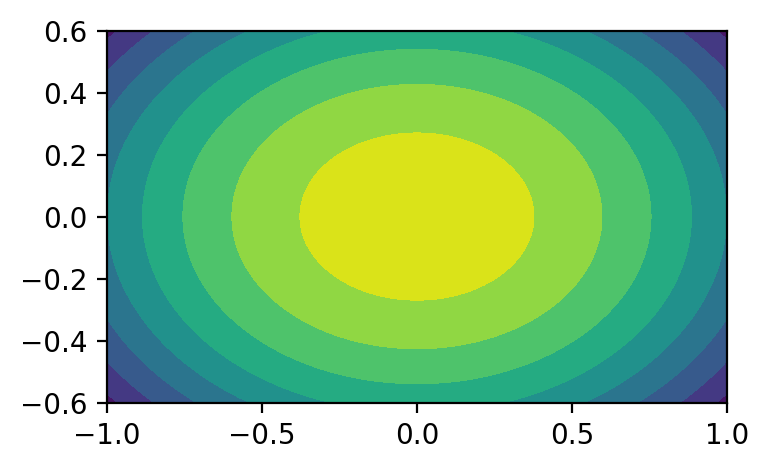

In [10]:
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(111)
ax.contourf(xx, yy, pot)
ax.set_aspect('equal')
plt.show()

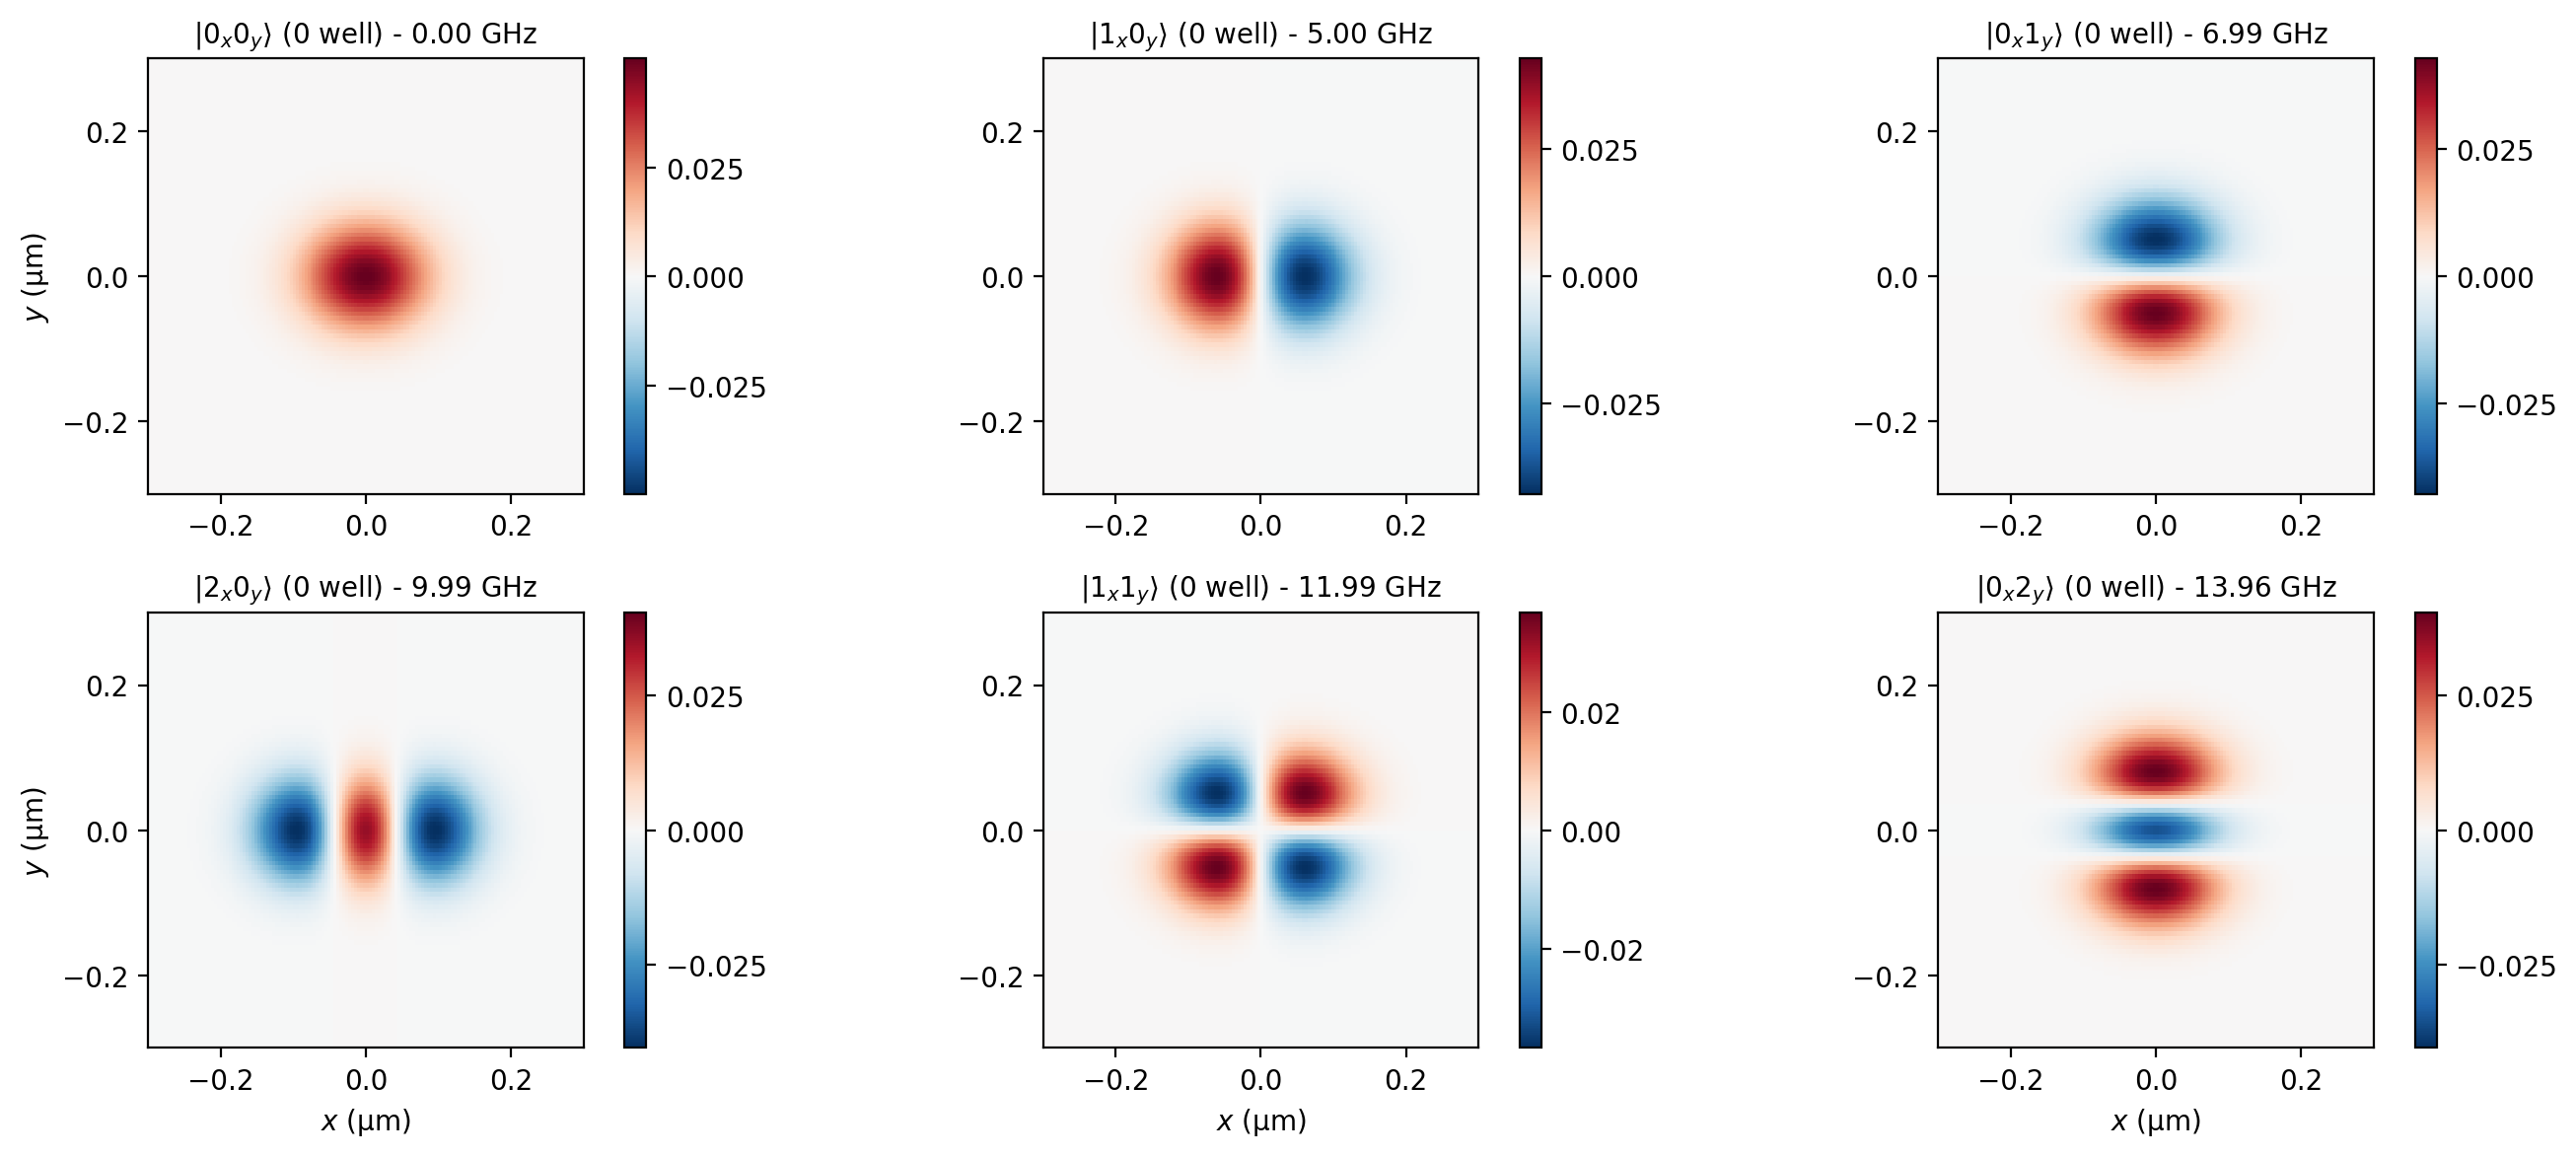

In [12]:
qa = SingleElectron(xx, yy, potential=pot, x_unit=1e-6, qaxis='x')
qa.solve_system(coor=None, dxdy=[0.6,0.6])
qa.plot_wavefunctions()

In [38]:
qa.classifier.classify_wavefunction_by_xy()

[{'nx': 0, 'ny': 0},
 {'nx': 1, 'ny': 0},
 {'nx': 0, 'ny': 1},
 {'nx': 2, 'ny': 0},
 {'nx': 1, 'ny': 1},
 {'nx': 0, 'ny': 2},
 {'nx': 3, 'ny': 0},
 {'nx': 2, 'ny': 1},
 {'nx': 1, 'ny': 2},
 {'nx': 4, 'ny': 0}]

In [13]:
qa.mode_frequencies

array([0.00000000e+00, 4.99302311e+09, 6.97245346e+09, 9.97812869e+09,
       1.19654766e+10, 1.39171888e+10, 1.49555439e+10, 1.69505822e+10,
       1.89102119e+10, 1.99251974e+10])

In [29]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np
def f(x, y):
    return 2 * x**3 + 3 * y**2
x = np.linspace(1, 4, 11)
y = np.linspace(4, 7, 22)
xg, yg = np.meshgrid(x, y, indexing='ij', sparse=True)
data = f(xg, yg)

In [30]:
interp = RegularGridInterpolator((x, y), data)

pts = np.array([[2.1, 6.2], [3.3, 5.2]])
interp(pts)

array([134.10469388, 153.40069388])

In [35]:
float(interp((1, 4)))

50.0

In [34]:
x1 = np.linspace(1, 4, 2)
y1 = np.linspace(4, 7, 2)
xg1, yg1 = np.meshgrid(x1, y1, indexing='ij', sparse=True)

interp((xg1, yg1))

array([[ 50., 149.],
       [176., 275.]])

In [9]:
from zeroheliumkit.helpers.constants import *

In [11]:
2*me * 1e-12/hbar**2 * qe

26243948.622769415

In [9]:
a, b, c = qa.get_quantum_spectrum(coor=None, dxdy=[0.6,0.58], plot_wavefunctions=True)

(np.float64(0.54), np.float64(0.0))


In [10]:
se = SingleElectron(x=a, y=b, x_unit=1e-6, potential_function=c, solve=False)
tt = se.evaluate_potential(se.x, se.y)

In [11]:
se.sparsify(num_levels=6)

In [12]:
se.solve(sparse_args=se.sparse_args)

(array([626607.78164257, 626607.78164257, 660803.80916852, 660803.80916852,
        687520.61854156, 687520.61854156]),
 array([[ 2.38910644e-16, -3.30303871e-16,  9.27531035e-17, ...,
         -8.24582686e-02,  9.06446769e-02, -6.40424590e-02],
        [-2.17537757e-16,  2.26373043e-16, -4.21062095e-17, ...,
          5.19411655e-01, -5.70978537e-01,  4.03408902e-01],
        [-1.27092147e-16,  1.61824729e-16, -3.63151472e-17, ...,
          1.88469804e-03,  1.87807171e-02, -2.18188430e-02],
        [-4.98053455e-19,  5.65629761e-17, -1.70184677e-17, ...,
          3.25433691e-02,  3.24289512e-01, -3.76749296e-01],
        [ 5.78315245e-16, -5.79607514e-16,  2.63860080e-16, ...,
          1.73197240e-02,  1.01170674e-02, -2.36694492e-02],
        [ 1.44454242e-16, -1.36290688e-16,  6.44068797e-17, ...,
          2.56610507e-01,  1.49895333e-01, -3.50688577e-01]],
       shape=(6, 14504)))

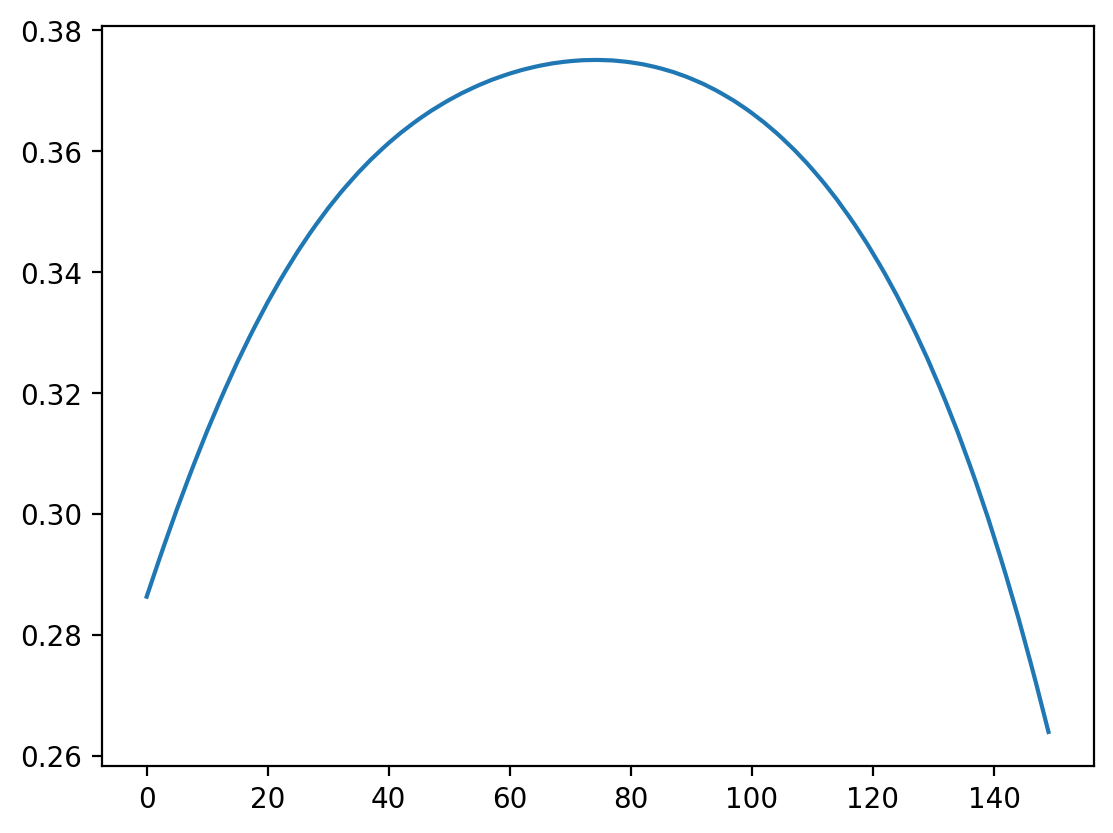

In [14]:
plt.plot(tt[51,:])

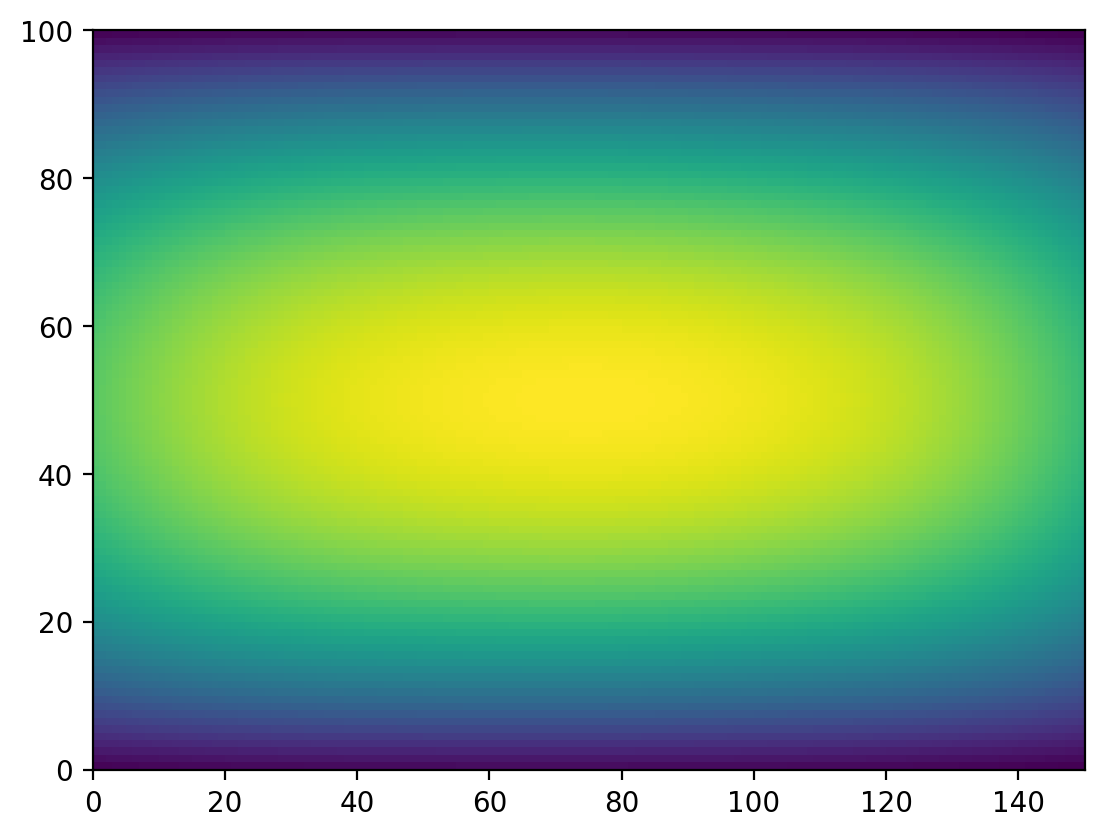

In [11]:
plt.pcolormesh(tt)

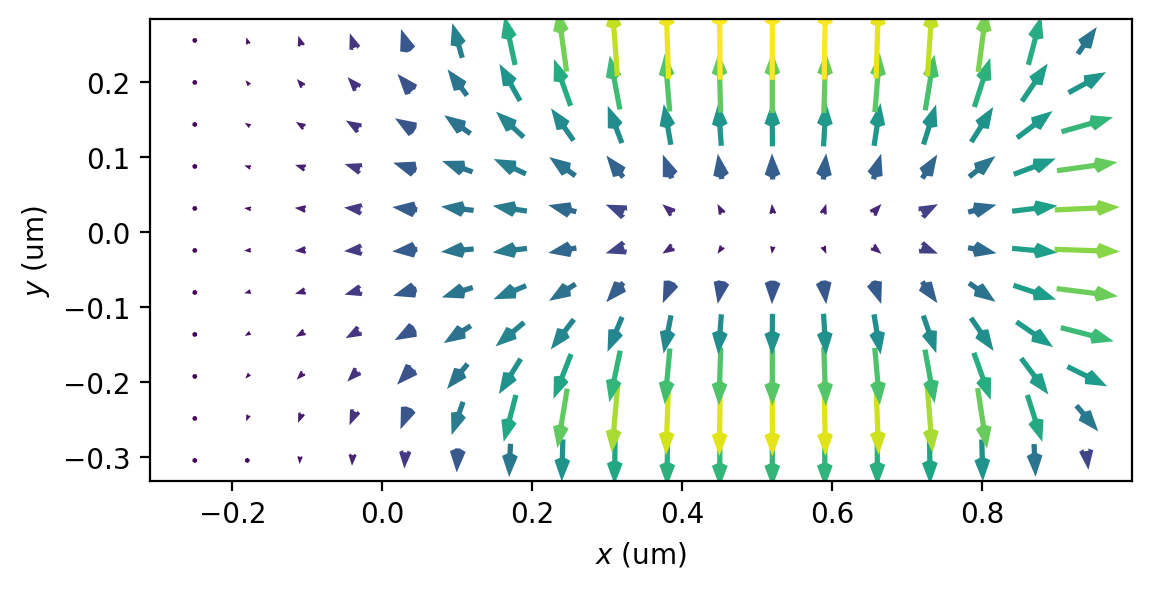

In [9]:
fig = plt.figure(figsize=(8, 3))
ax = fig.add_subplot(111)
fa.plot2D_vectorfield(step=7, units='xy', pivot='mid', scale=20., width=0.007, headwidth=3., headlength=4.)
ax.set_aspect("equal")
plt.show()

In [11]:
wlist = ["width_1000nm", "width_800nm", "width_600nm", "width_500nm", "width_400nm", "width_300nm"]

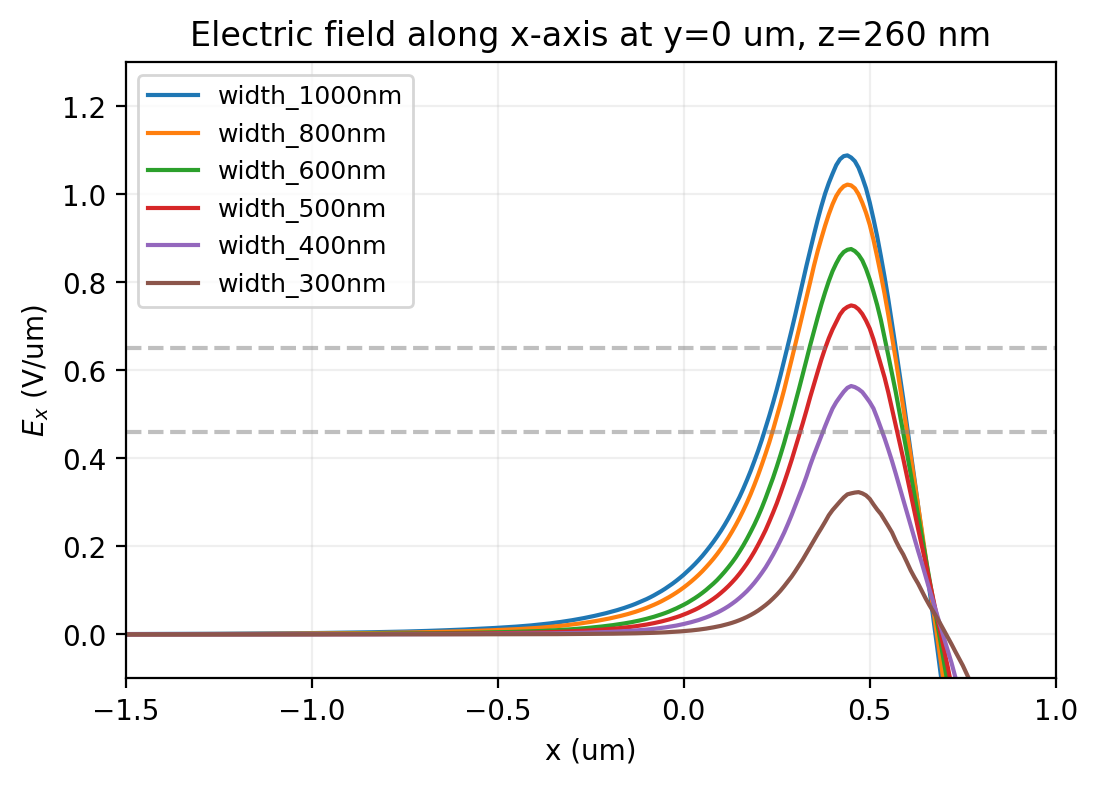

In [15]:
voltages = {
    'ch':       0,
    'a':        0, 
    'b':        0,
    'c':        0,
    'res':      1,
    'top':      0,
}
# x,y = fa.get_field_1D(fa.dot, voltages, xy_cut="x", loc=0, zlevel_key=0.29)

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)

for dirname in wlist:
    ffparser = FreeFemResultParser(dirname + "/metadata.yaml", show=False)
    ffparser.load_data(dirname + "/results/", "result2")
    fa = FieldAnalyzer(ffparser.get_coupling_constants(slice_value=0.26, round_with_decimals=6))
    fa.set_voltages(voltages)
    fa.plot1D_gradient(grad_axis="x", slice=("x",0), ax=ax, label=dirname)
    # x, y = fa.get_field_1D(fa.dot, voltages, xy_cut="x", loc=0, zlevel_key=0.26)
    # ax.plot(x, y, '-', label=dirname)


# ax.plot(x, y, 'o')
ax.set_xlabel("x (um)")
ax.set_ylabel(r"$E_x$ (V/um)")
ax.set_title("Electric field along x-axis at y=0 um, z=260 nm")
ax.hlines([0.46,0.65], xmin=-1.5, xmax=1, colors='gray', linestyles='dashed', alpha=0.5)
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
ax.set_ylim(-0.1,1.3)
ax.set_xlim(-1.5,1.0)
plt.show()

In [11]:
from dataclasses import dataclass
from zeroheliumkit.helpers.constants import me, hbar, qe

@dataclass
class ScalingFactors:
    k: float  # Kinetic energy scaling factor
    u: float  # Potential energy scaling factor
    E: float  # Energy scaling factor
    f: float  # Frequency scaling factor

    def __init__(self, x_unit: float=1e-6):
        Escale = 2 * me * x_unit**2 / hbar**2
        self.k = -1
        self.u = qe * Escale
        self.E = Escale
        self.f = 1 / Escale / hbar / 2 / np.pi

In [13]:
sf = ScalingFactors(x_unit=1e-6)
sf.k

-1

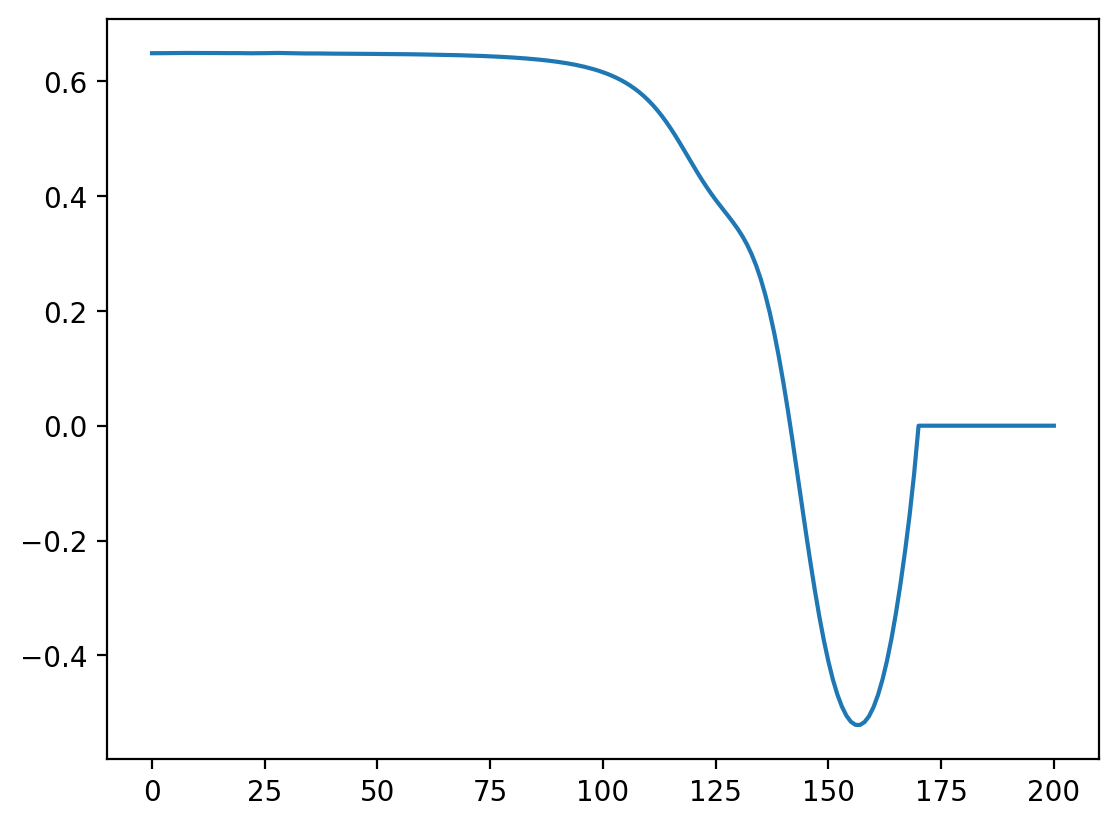

In [ ]:
cpw_params = {"f_resonator": 7.16e9, "C_cpw": 5.25e-15, "C_dot": 0.018e-15, "electrode_names": ["res"], "type": "1/4"}

ec = ExperimentCompanion(
    coupling_constants=curve.efield,
    dot_area=dot_area,
    links=None,
    exp_voltages=voltages,
    fit_function="auto",
    resonator_params=cpw_params,
    Ez_coupling_constants=Ez.interpolated,
    filter_data=False
)